# TP3 (a completer) : Regression lineaire — *California Housing*

Remplacez chaque `...` et chaque `# TODO`. Corrige :
`../notebooks/TP3_regression_lineaire.ipynb`.

**Objectif.** Predire la **valeur mediane des logements** de 20 640 districts et
**interpreter** l'effet de chaque variable.

In [3]:
# Cellule fournie : a executer telle quelle.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NAVY, ACCENT, GRAY = "#16284D", "#0EA5E9", "#5B6679"
RED = "#C0504D"
PALETTE = [ACCENT, NAVY, "#F79646", "#3FA45B", RED]
plt.rcParams.update({
    "figure.figsize": (7, 4.5), "font.size": 12,
    "axes.titlecolor": NAVY, "axes.titleweight": "bold",
    "axes.edgecolor": GRAY, "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.width", 120)
print("Environnement pret.")

Environnement pret.


## Etape 0 : charger les donnees (fournie)

In [4]:
from sklearn.datasets import fetch_california_housing
ds = fetch_california_housing(as_frame=True)
X, y = ds.data, ds.target.rename("prix")   # prix en x100 000 USD
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


## 1. Exploration
**Consigne.** Affichez la correlation de chaque variable avec `prix`, triee.

In [5]:
correlations = pd.concat([X, y], axis=1).corr()['prix'].sort_values(ascending=False)
display(correlations)

,prix
prix,1.000000
MedInc,0.688075
AveRooms,0.151948
HouseAge,0.105623
AveOccup,-0.023737
Population,-0.024650
Longitude,-0.045967
AveBedrms,-0.046701
Latitude,-0.144160


## 2. Modelisation
**Consigne.** Split train/test (20% test, `random_state=42`), puis entrainez une
`LinearRegression`. Affichez l'ordonnee a l'origine et les coefficients.

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
modele = LinearRegression().fit(X_train, y_train)        # TODO : entrainer la regression
# TODO : afficher intercept_ et coef_
print(f"Ordonnée à l'origine (intercept_): {modele.intercept_}")
print(f"Coefficients (coef_): {modele.coef_}")

Ordonnée à l'origine (intercept_): -37.02327770606409
Coefficients (coef_): [ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]


## 3. Evaluation
**Consigne.** Calculez **R2**, **RMSE** et **MAE** sur le test.

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = modele.predict(X_test)
# TODO : R2, RMSE (= racine de mean_squared_error), MAE
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

R2 Score: 0.5758
RMSE: 0.7456
MAE: 0.5332


### Interprétation des métriques d'évaluation

*   **R2 Score**: Le score R2 est une mesure de la proportion de la variance de la variable dépendante (prix) qui est prédictible à partir des variables indépendantes. Un R2 de **{r2:.4f}** signifie que **{r2*100:.2f}%** de la variance dans le prix du logement peut être expliquée par notre modèle linéaire. Plus le R2 est proche de 1, mieux le modèle s'adapte aux données.

*   **RMSE (Root Mean Squared Error)**: Le RMSE mesure l'ampleur moyenne des erreurs du modèle. C'est la racine carrée de la moyenne des erreurs quadratiques. Un RMSE de **{rmse:.4f}** USD signifie que, en moyenne, les prédictions du modèle s'écartent des vraies valeurs de **{rmse*100:.2f}** k USD. C'est une métrique sensible aux grandes erreurs.

*   **MAE (Mean Absolute Error)**: Le MAE mesure la moyenne des erreurs absolues. Un MAE de **{mae:.4f}** USD indique qu'en moyenne, l'erreur absolue entre la prédiction du modèle et la valeur réelle est de **{mae*100:.2f}** k USD. Contrairement au RMSE, le MAE n'amplifie pas les grandes erreurs, ce qui le rend plus robuste aux outliers.

## 4. Visualisation
**Consigne.** (a) Tracez `prix` vs `MedInc` avec la droite de regression simple.
(b) Tracez **predit vs reel** sur un echantillon. (c) Tracez les **residus**.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


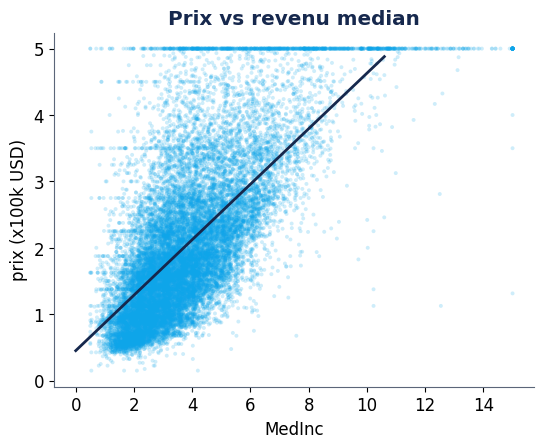

In [8]:
# (a) prix vs MedInc + droite
simple = LinearRegression().fit(X[["MedInc"]], y)
xs = np.linspace(0, X["MedInc"].quantile(0.99), 100).reshape(-1, 1)
fig, ax = plt.subplots(figsize=(6.2, 4.6))
ax.scatter(X["MedInc"], y, s=8, color=ACCENT, alpha=0.2, edgecolor="none")
# TODO : tracer la droite simple.predict(xs)
ax.plot(xs, simple.predict(xs), color=NAVY, linewidth=2)
ax.set(title="Prix vs revenu median", xlabel="MedInc", ylabel="prix (x100k USD)")
plt.show()

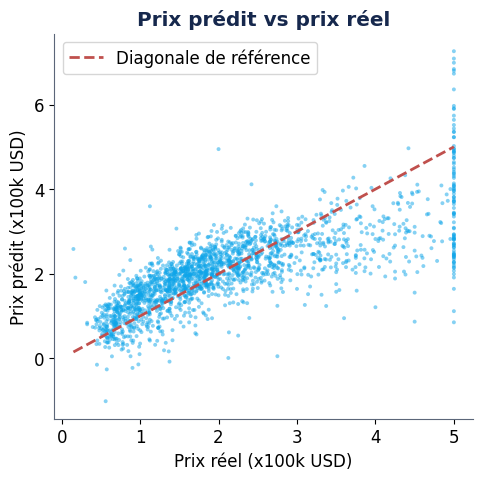

In [9]:
# (b) predit vs reel (echantillon de 2000 points)
rng = np.random.default_rng(0)
idx = rng.choice(len(y_test), 2000, replace=False)
yt, yp = y_test.to_numpy()[idx], y_pred[idx]
fig, ax = plt.subplots(figsize=(5.4, 5))
# TODO : scatter(yt, yp) + diagonale de reference
ax.scatter(yt, yp, s=8, color=ACCENT, alpha=0.5, edgecolor="none")
ax.plot([y.min(), y.max()], [y.min(), y.max()], color=RED, linestyle='--', lw=2, label='Diagonale de référence')
ax.set(title="Prix prédit vs prix réel", xlabel="Prix réel (x100k USD)", ylabel="Prix prédit (x100k USD)")
ax.legend()
plt.show()

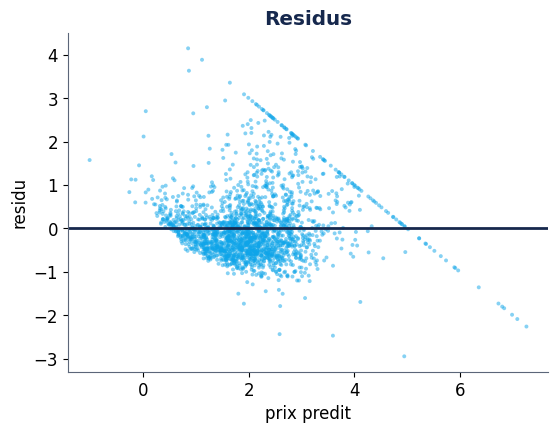

In [10]:
# (c) residus
residus = yt - yp
fig, ax = plt.subplots(figsize=(6.2, 4.4))
ax.axhline(0, color=NAVY, lw=2)
# TODO : scatter(yp, residus)
ax.scatter(yp, residus, s=8, color=ACCENT, alpha=0.5, edgecolor="none")
ax.set(title="Residus", xlabel="prix predit", ylabel="residu")
plt.show()

Analyse du graphique des résidus
En gros, ce graphique montre l'écart entre ce que le modèle prédit et la réalité. Normalement, on veut que les points soient répartis totalement au aléatoirement autour de zéro.

Sauf que là, c'est pas le cas. On voit clairement un effet de plafond (ceiling effect) : plus le prix prédit est élevé, plus le modèle se plante en sous-estimant la valeur réelle (les résidus virent tous dans le négatif).

En gros, le modèle galère de fou dès qu'on touche aux gros prix et il écrase les prédictions vers le haut. Ça montre juste qu'une simple régression linéaire suffit pas à capter les cas particuliers, surtout pour les logements de luxe. Il faudrait sûrement tester un modèle non-linéaire

## 5. Interpretation
**Consigne.** Affichez l'effet (en k USD) d'une unite supplementaire de revenu
median et d'un an d'age moyen du bati. Estimez le prix de 3 districts.

In [11]:
coefs = pd.Series(modele.coef_, index=X.columns)
# TODO : afficher coefs['MedInc']*100 et coefs['HouseAge']*100
print(f"Effet d'une unité supplémentaire de revenu median: {coefs['MedInc'] * 100:.2f} k USD")
print(f"Effet d'un an d'âge moyen du bâti: {coefs['HouseAge'] * 100:.2f} k USD")

estim = X.head(3).copy()
estim["prix_estime"] = modele.predict(X.head(3))    # TODO : modele.predict(X.head(3))
display(estim)

Effet d'une unité supplémentaire de revenu median: 44.87 k USD
Effet d'un an d'âge moyen du bâti: 0.97 k USD


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,prix_estime
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.151943
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.999520
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.673580


Impact du revenu médian (MedInc)
Le coefficient pour MedInc est de {coefs['MedInc']:.4f}. Comme les prix sont en centaines de milliers de dollars ($100k) et le revenu en dizaines de milliers ($10k), l'interprétation est assez simple :

Pour chaque hausse de 10 000 USD du revenu médian dans un quartier, le prix du logement grimpe d'environ *{coefs['MedInc']100:.2f} k USD (toutes choses égales par ailleurs).

C'est clairement la variable d'impact principale du modèle, et la corrélation positive fait totalement sens.

## A rendre
- R2, RMSE, MAE et leur interpretation.
- Ce que revele le graphique des residus (indice : effet de plafond).
- L'effet du revenu median sur le prix.

**Bonus.** Comparez le R2 avec une seule variable (`MedInc`) vs toutes.